# Evaluation

해당 지표의 값은 모두 0에 가까울 수록 모델 성능이 좋음
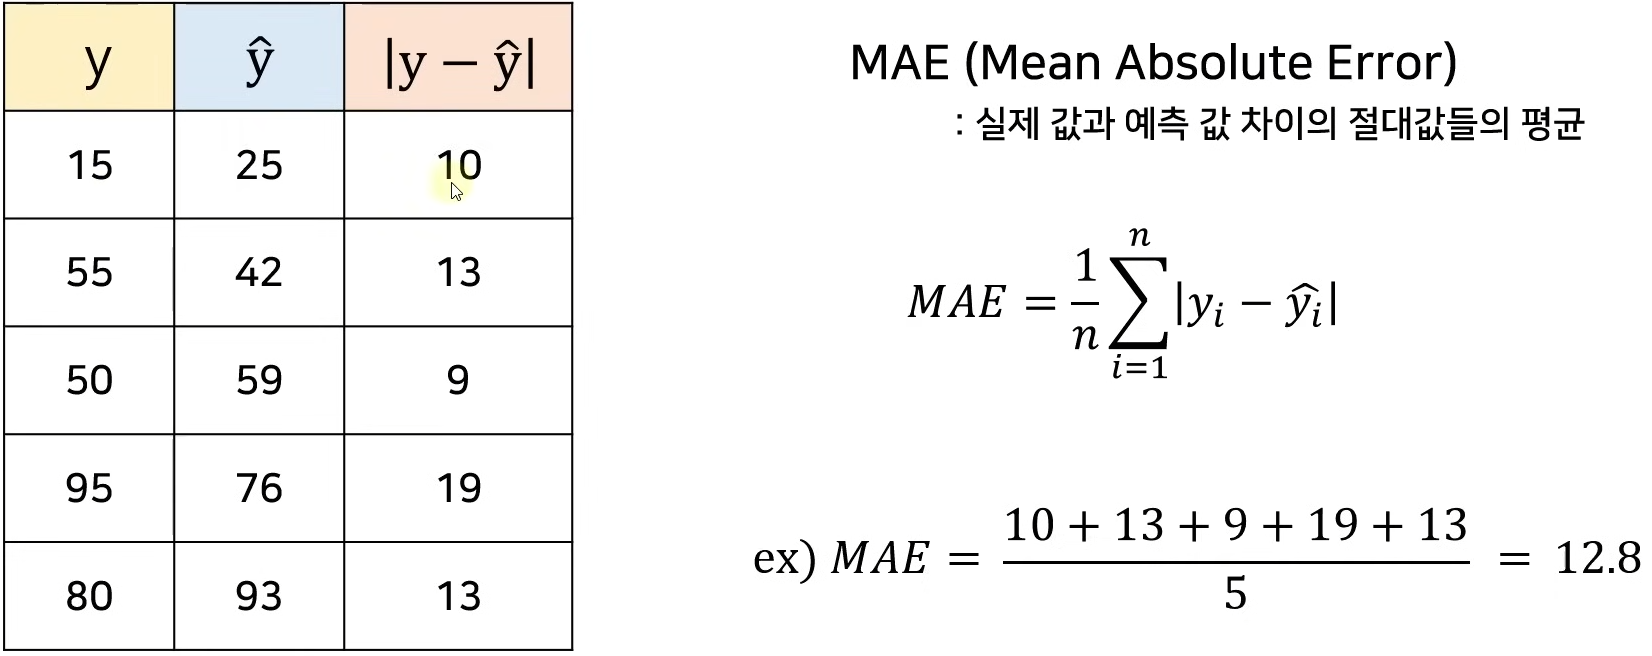
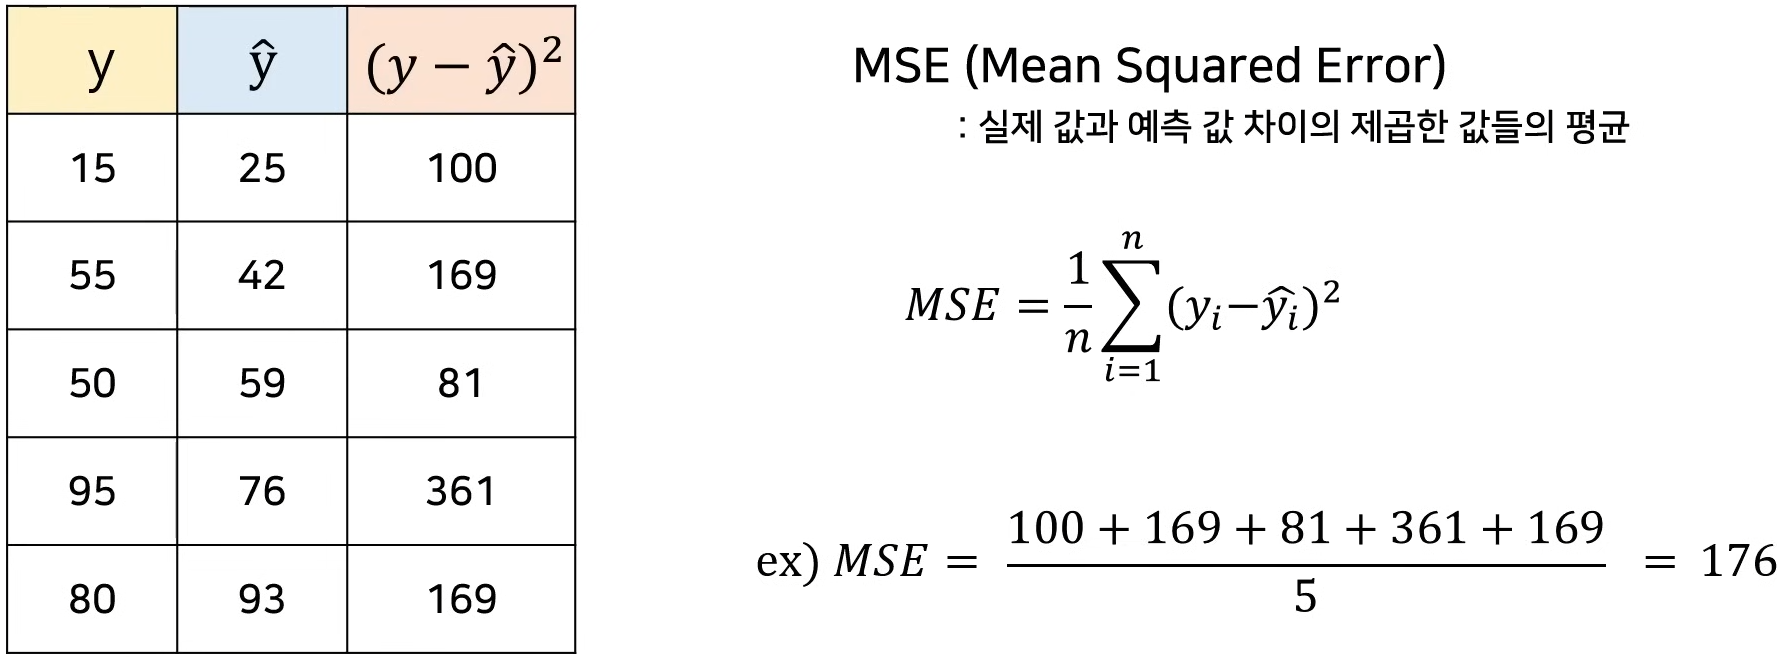
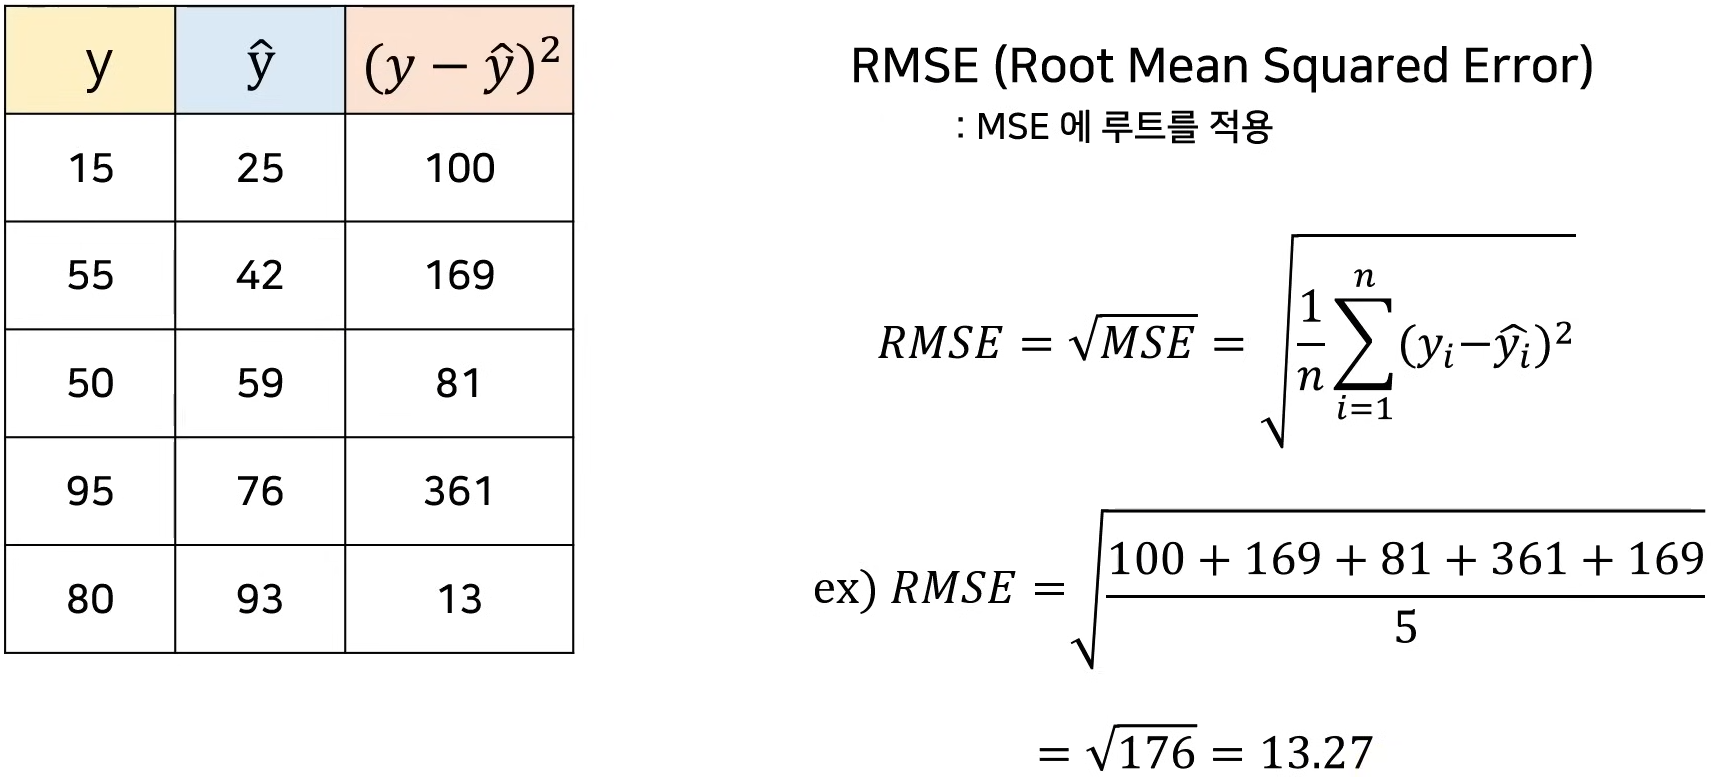
--------------------------------------------------------------------------------------------------------------------------------
1에 가까울수록 좋다, 0에 가까울수록 나쁘다.
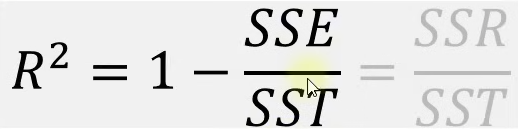
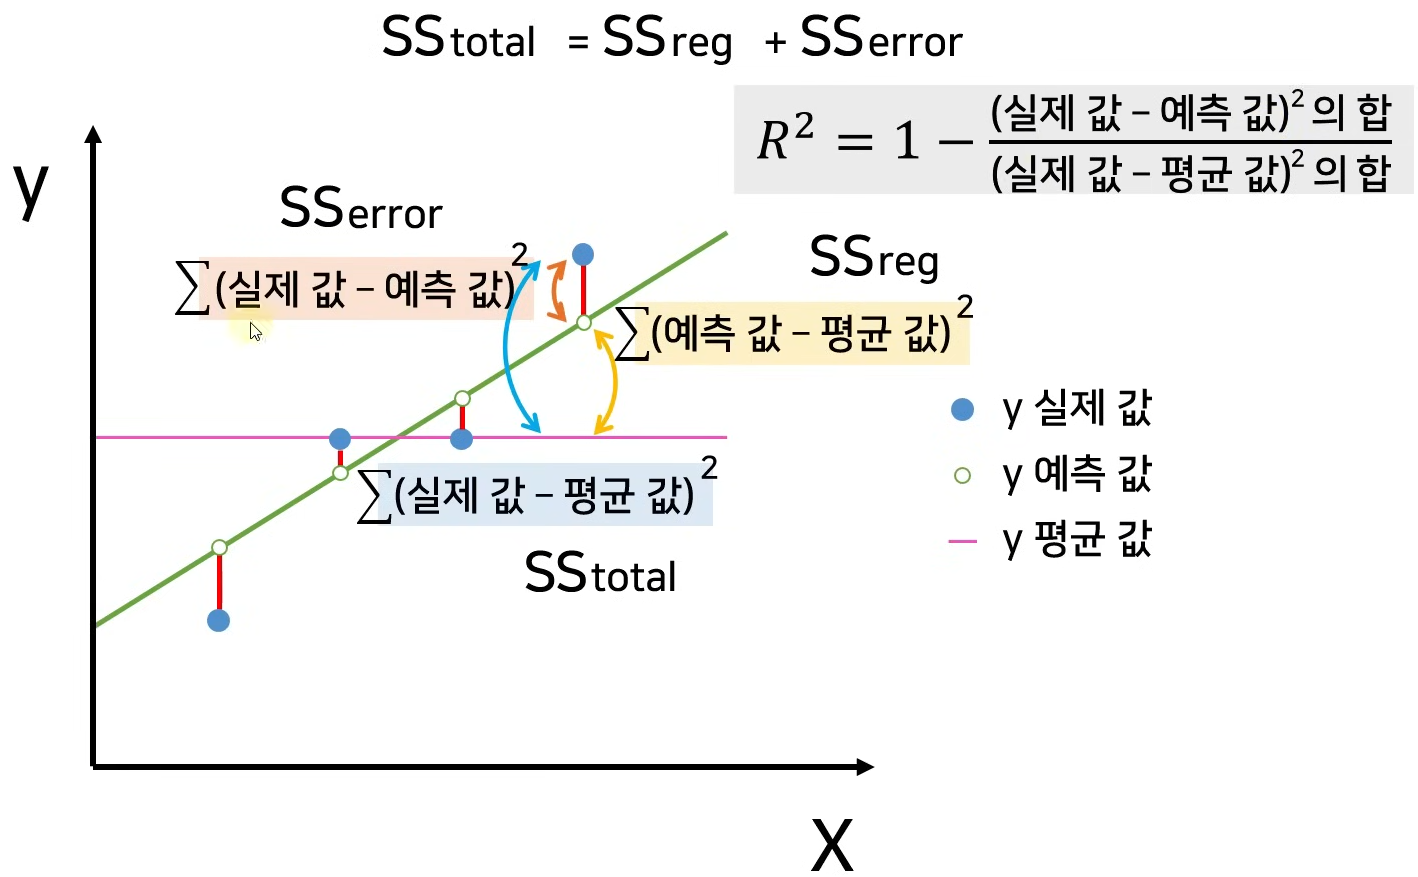
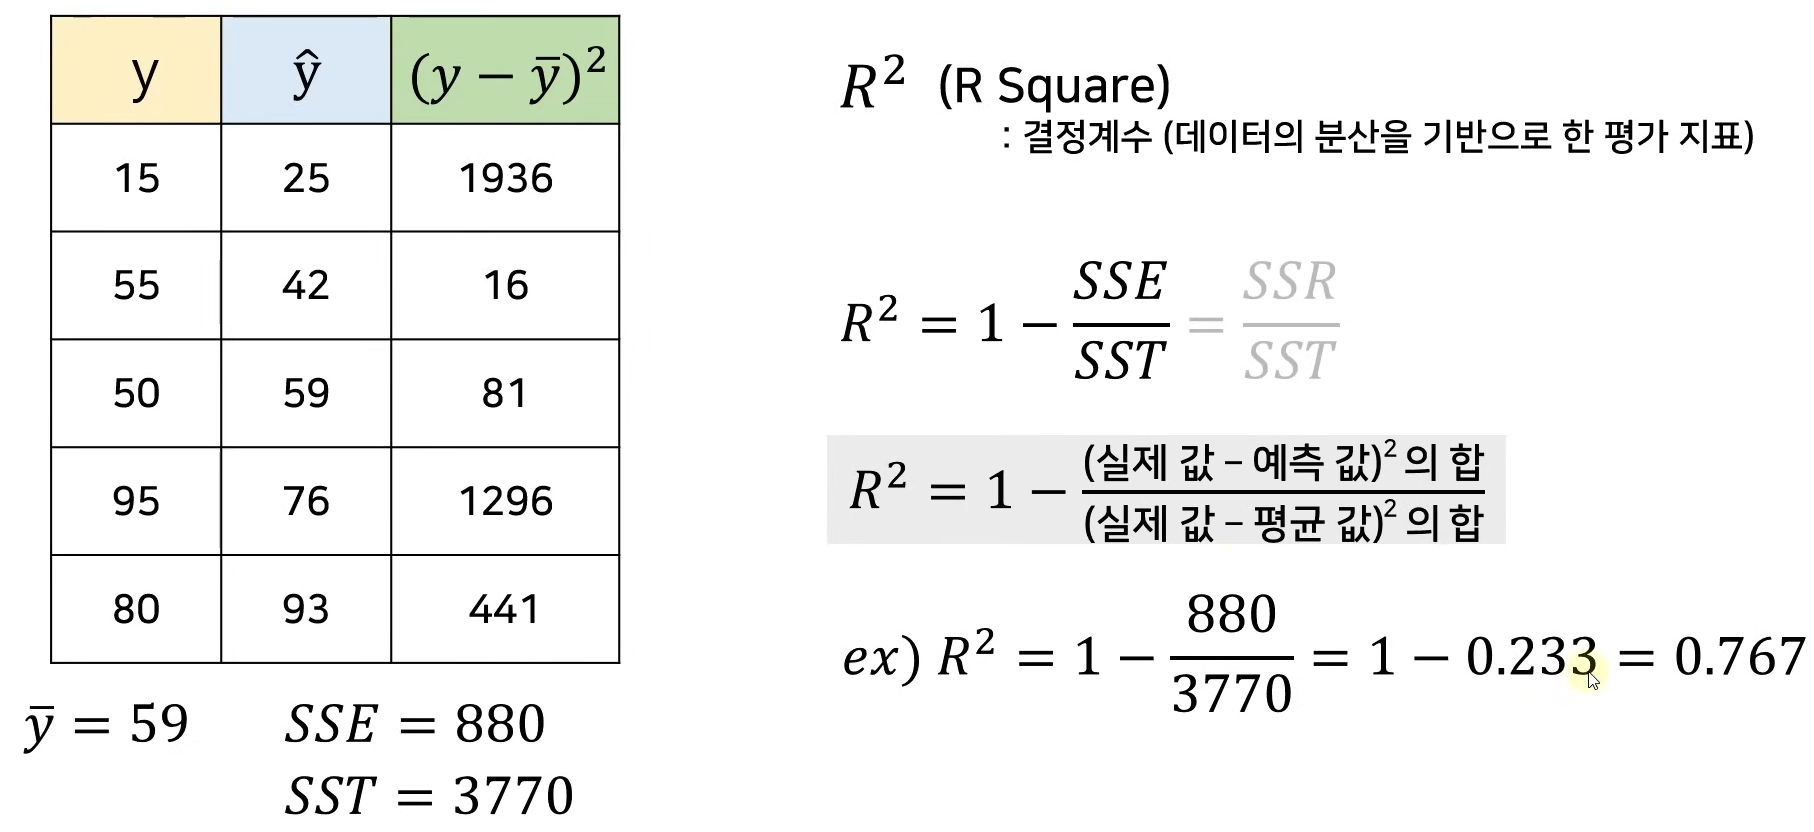

In [5]:
import pandas as pd
dataSet = pd.read_csv('MultipleLinearRegressionData.csv')
X = dataSet.iloc[:,:-1].values
y = dataSet.iloc[:,-1].values
X

array([[0.5, 3, 'Home'],
       [1.2, 4, 'Library'],
       [1.8, 2, 'Cafe'],
       [2.4, 0, 'Cafe'],
       [2.6, 2, 'Home'],
       [3.2, 0, 'Home'],
       [3.9, 0, 'Library'],
       [4.4, 0, 'Library'],
       [4.5, 5, 'Home'],
       [5.0, 1, 'Cafe'],
       [5.3, 2, 'Cafe'],
       [5.8, 0, 'Cafe'],
       [6.0, 3, 'Library'],
       [6.1, 1, 'Cafe'],
       [6.2, 1, 'Library'],
       [6.9, 4, 'Home'],
       [7.2, 2, 'Cafe'],
       [8.4, 1, 'Home'],
       [8.6, 1, 'Library'],
       [10.0, 0, 'Library']], dtype=object)

In [7]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

ct = ColumnTransformer(transformers=[('encoder', OneHotEncoder(drop='first'),[2])], remainder='passthrough')
X = ct.fit_transform(X)
X

array([[1.0, 0.0, 0.5, 3],
       [0.0, 1.0, 1.2, 4],
       [0.0, 0.0, 1.8, 2],
       [0.0, 0.0, 2.4, 0],
       [1.0, 0.0, 2.6, 2],
       [1.0, 0.0, 3.2, 0],
       [0.0, 1.0, 3.9, 0],
       [0.0, 1.0, 4.4, 0],
       [1.0, 0.0, 4.5, 5],
       [0.0, 0.0, 5.0, 1],
       [0.0, 0.0, 5.3, 2],
       [0.0, 0.0, 5.8, 0],
       [0.0, 1.0, 6.0, 3],
       [0.0, 0.0, 6.1, 1],
       [0.0, 1.0, 6.2, 1],
       [1.0, 0.0, 6.9, 4],
       [0.0, 0.0, 7.2, 2],
       [1.0, 0.0, 8.4, 1],
       [0.0, 1.0, 8.6, 1],
       [0.0, 1.0, 10.0, 0]], dtype=object)

In [8]:
#데이터 세트 분리
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=0)

In [9]:
#모델 학습(다중 선형 회귀)
from sklearn.linear_model import LinearRegression
reg = LinearRegression()
reg.fit(X_train, y_train)

LinearRegression()

In [10]:
y_pred = reg.predict(X_test)
y_pred

array([ 92.15457859,  10.23753043, 108.36245302,  38.14675204])

In [11]:
y_test

array([ 90,   8, 100,  38], dtype=int64)

In [12]:
reg.coef_

array([-5.82712824, -1.04450647, 10.40419528, -1.64200104])

In [13]:
reg.intercept_

5.365006706544804

### 모델 평가

In [26]:
reg.score(X_train,y_train) #훈련세트

0.9623352565265527

In [27]:
reg.score(X_test, y_test) #테스트세트

0.9859956178877447

### 다양한 평가 지표(회귀 모델)

1. MAE(Mean Absolute Error): (셀제 값과 예측 값) 차이의 절대값
2. MSE(Mean Squared Error): (셀제 값과 예측 값) 차이의 제곱
3. RMSE(Root Mean Squared Error): (셀제 값과 예측 값) 차이의 제곱에 루트
4. R2: 결정 계수
> R2는 1에 가까울수록, 그 외는 0에 가까울 수록 좋은 모델임

In [18]:
#다양한 평가 지표(회귀 모델)
from sklearn.metrics import mean_squared_error
mean_squared_error(y_test, y_pred) #실제값, 예측값 #MAEreg.score(X_test, y_test) #테스트세트

19.900226981514795

In [23]:
from sklearn.metrics import mean_squared_error
mean_squared_error(y_test, y_pred) #MSE

19.900226981514795

In [24]:
from sklearn.metrics import mean_squared_error
mean_squared_error(y_test, y_pred, squared=False) #RMSE

4.460967045553553

In [25]:
from sklearn.metrics import r2_score
r2_score(y_test, y_pred) #R2

0.9859956178877447

참고로 reg.score()로 나온 값이 r2_score과 같다.
그렇기에 R2가 아닌 다른 평가지표 MAE, MSE, RMSE의 값이 필요하다면
위에 방법으로 사용하면 된다.